# Лабораторная работа №7
## Полносвязные нейронные сети (FCNN) для задач регрессии и классификации

**Датасет регрессии:** Moldova Cars — `Price(euro)`  
**Датасет классификации:** Diabetes Health Indicators — `Diabetes_012`  
**Фреймворки:** Scikit-learn MLP, Keras/TensorFlow  
**Методы подбора:** Optuna, RandomizedSearchCV, Hyperopt, KerasTuner, Ray Tune

> 💾 **Кеширование:** каждая ячейка сохраняет результат в файл и при повторном запуске загружает его, пропуская долгое обучение.

In [21]:
# ⚠️ Запустите ПЕРВОЙ при ошибке pkg_resources
import subprocess, sys
for mod in list(__import__('sys').modules.keys()):
    if 'hyperopt' in mod or 'pkg_resources' in mod:
        del __import__('sys').modules[mod]
print("✅ Готово")

✅ Готово


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, pickle
warnings.filterwarnings('ignore')

import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.utils import resample
from scipy.stats import loguniform

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
import keras_tuner as kt

RANDOM_STATE = 42
CACHE_DIR = Path('lab7_cache')
CACHE_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow: {tf.__version__}  |  Keras: {keras.__version__}")
print(f"Optuna: {optuna.__version__}")
print(f"Кеш-директория: {CACHE_DIR.resolve()}")
print("✅ Импорты выполнены!")

TensorFlow: 2.21.0  |  Keras: 3.13.2
Optuna: 4.7.0
Кеш-директория: /home/alexey-rau/projects/omgtu/OMGTU/2year/4semester/MLDA/Лабораторная работа №7. Полносвязные нейронные сети (FCNN). Решение задач регрессии и классификации/lab7_cache
✅ Импорты выполнены!


---
## 2. Загрузка и подготовка данных
### 2.1. Загрузка датасетов

In [23]:
df_reg   = pd.read_csv('../datasets/filtered_moldova_cars_task.csv')
df_class = pd.read_csv('../datasets/filtered_diabetes_health_indicators.csv')

print("РЕГРЕССИЯ:", df_reg.shape, "| целевая: Price(euro)")
print(df_reg.describe())
print("\nКЛАССИФИКАЦИЯ:", df_class.shape, "| целевая: Diabetes_012")
print(df_class['Diabetes_012'].value_counts().sort_index())

РЕГРЕССИЯ: (27137, 11) | целевая: Price(euro)
               Make         Model          Year         Style       Distance  \
count  27137.000000  27137.000000  27137.000000  27137.000000   27137.000000   
mean      45.454251    328.825441   2008.383535      7.499613  180189.043262   
std       20.889195    183.193466      6.609078      3.253718   85220.152917   
min        0.000000      0.000000   1989.000000      0.000000    1000.000000   
25%       30.000000    173.000000   2005.000000      4.000000  125069.000000   
50%       51.000000    315.000000   2010.000000      9.000000  180000.000000   
75%       67.000000    467.000000   2013.000000     10.000000  231861.000000   
max       73.000000    674.000000   2021.000000     11.000000  435000.000000   

       Engine_capacity(cm3)     Fuel_type  Transmission   Price(euro)  \
count          27137.000000  27137.000000  27137.000000  27137.000000   
mean            1742.782474      1.911412      0.611895   7466.191731   
std           

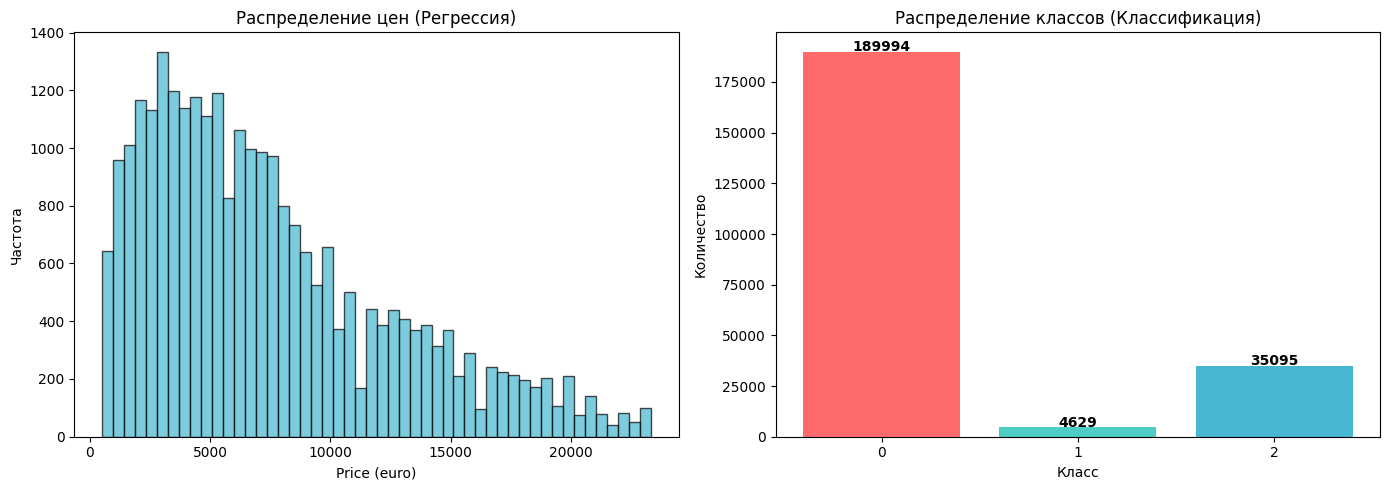

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(df_reg['Price(euro)'], bins=50, color='#45b7d1', edgecolor='black', alpha=0.7)
axes[0].set(title='Распределение цен (Регрессия)', xlabel='Price (euro)', ylabel='Частота')

class_counts = df_class['Diabetes_012'].value_counts().sort_index()
axes[1].bar(class_counts.index.astype(str), class_counts.values, color=['#ff6b6b','#4ecdc4','#45b7d1'])
axes[1].set(title='Распределение классов (Классификация)', xlabel='Класс', ylabel='Количество')
for i,v in enumerate(class_counts.values):
    axes[1].text(i, v+100, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150); plt.show()

### 2.2. Подготовка признаков и масштабирование

In [25]:
_cache = CACHE_DIR / 'data_prep.pkl'

if _cache.exists():
    print("📂 Загружаем подготовленные данные из кеша...")
    _d = joblib.load(_cache)
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = _d['reg']
    X_train_class, X_test_class, y_train_class, y_test_class = _d['cls']
    scaler_reg, scaler_class, scaler_y_reg = _d['scalers']
    X_train_reg_scaled, X_test_reg_scaled = _d['reg_scaled']
    X_train_class_scaled, X_test_class_scaled = _d['cls_scaled']
    y_train_reg_scaled, y_test_reg_scaled = _d['y_scaled']
else:
    y_reg   = df_reg['Price(euro)'].values
    X_reg   = df_reg.drop(columns=['Price(euro)'])
    y_class = df_class['Diabetes_012'].values
    X_class = df_class.drop(columns=['Diabetes_012'])

    X_train_reg,   X_test_reg,   y_train_reg,   y_test_reg   = train_test_split(X_reg,   y_reg,   test_size=0.2, random_state=RANDOM_STATE)
    X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class)

    # Сэмплируем классификацию до 15 000
    MAX_TRAIN_CLASS = 15000
    if X_train_class.shape[0] > MAX_TRAIN_CLASS:
        X_train_class, y_train_class = resample(X_train_class, y_train_class,
            n_samples=MAX_TRAIN_CLASS, random_state=RANDOM_STATE, stratify=y_train_class)

    scaler_reg, scaler_class, scaler_y_reg = StandardScaler(), StandardScaler(), StandardScaler()

    X_train_reg_scaled   = scaler_reg.fit_transform(X_train_reg)
    X_test_reg_scaled    = scaler_reg.transform(X_test_reg)
    X_train_class_scaled = scaler_class.fit_transform(X_train_class)
    X_test_class_scaled  = scaler_class.transform(X_test_class)
    y_train_reg_scaled   = scaler_y_reg.fit_transform(y_train_reg.reshape(-1,1)).ravel()
    y_test_reg_scaled    = scaler_y_reg.transform(y_test_reg.reshape(-1,1)).ravel()

    joblib.dump({'reg': (X_train_reg, X_test_reg, y_train_reg, y_test_reg),
                 'cls': (X_train_class, X_test_class, y_train_class, y_test_class),
                 'scalers': (scaler_reg, scaler_class, scaler_y_reg),
                 'reg_scaled': (X_train_reg_scaled, X_test_reg_scaled),
                 'cls_scaled': (X_train_class_scaled, X_test_class_scaled),
                 'y_scaled': (y_train_reg_scaled, y_test_reg_scaled)}, _cache)
    print("💾 Данные сохранены в кеш.")

print(f"Регрессия:      Train={X_train_reg.shape[0]}, Test={X_test_reg.shape[0]}")
print(f"Классификация:  Train={X_train_class.shape[0]}, Test={X_test_class.shape[0]}")
print(f"y_reg: mean={y_train_reg.mean():.0f}€, std={y_train_reg.std():.0f}€")

📂 Загружаем подготовленные данные из кеша...
Регрессия:      Train=21709, Test=5428
Классификация:  Train=15000, Test=45944
y_reg: mean=7445€, std=5121€


### 2.3. K-Fold кросс-валидация

In [26]:
N_SPLITS = 5
kfold_reg   = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
kfold_class = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
print(f"K-Fold: {N_SPLITS} фолдов")
for i,(tr,vl) in enumerate(kfold_reg.split(X_train_reg_scaled)):
    print(f"  Fold {i+1}: Train={len(tr)}, Val={len(vl)}")

K-Fold: 5 фолдов
  Fold 1: Train=17367, Val=4342
  Fold 2: Train=17367, Val=4342
  Fold 3: Train=17367, Val=4342
  Fold 4: Train=17367, Val=4342
  Fold 5: Train=17368, Val=4341


### 2.4. Оптимизация признакового пространства (SelectKBest)

In [27]:
_cache = CACHE_DIR / 'features.pkl'

if _cache.exists():
    print("📂 Загружаем отбор признаков из кеша...")
    _f = joblib.load(_cache)
    X_train_reg_selected,   X_test_reg_selected   = _f['reg']
    X_train_class_selected, X_test_class_selected = _f['cls']
    selector_reg_final, selector_class_final       = _f['selectors']
else:
    # Регрессия
    sel_r = SelectKBest(f_regression, k='all').fit(X_train_reg_scaled, y_train_reg)
    sig_r = pd.DataFrame({'F': sel_r.scores_, 'p': sel_r.pvalues_},
                          index=df_reg.drop(columns=['Price(euro)']).columns)
    n_r = max((sig_r['p'] < 0.05).sum(), 5)
    selector_reg_final = SelectKBest(f_regression, k=n_r).fit(X_train_reg_scaled, y_train_reg)
    X_train_reg_selected = selector_reg_final.transform(X_train_reg_scaled)
    X_test_reg_selected  = selector_reg_final.transform(X_test_reg_scaled)

    # Классификация
    sel_c = SelectKBest(f_classif, k='all').fit(X_train_class_scaled, y_train_class)
    sig_c = pd.DataFrame({'F': sel_c.scores_, 'p': sel_c.pvalues_},
                          index=df_class.drop(columns=['Diabetes_012']).columns)
    n_c = max((sig_c['p'] < 0.05).sum(), 5)
    selector_class_final = SelectKBest(f_classif, k=n_c).fit(X_train_class_scaled, y_train_class)
    X_train_class_selected = selector_class_final.transform(X_train_class_scaled)
    X_test_class_selected  = selector_class_final.transform(X_test_class_scaled)

    joblib.dump({'reg': (X_train_reg_selected, X_test_reg_selected),
                 'cls': (X_train_class_selected, X_test_class_selected),
                 'selectors': (selector_reg_final, selector_class_final)}, _cache)
    print("💾 Признаки сохранены в кеш.")

INPUT_DIM_REG   = X_train_reg_selected.shape[1]
INPUT_DIM_CLASS = X_train_class_selected.shape[1]
NUM_CLASSES     = len(np.unique(y_train_class))
print(f"Input dim: Регрессия={INPUT_DIM_REG}, Классификация={INPUT_DIM_CLASS}, Классов={NUM_CLASSES}")

📂 Загружаем отбор признаков из кеша...
Input dim: Регрессия=10, Классификация=19, Классов=3


---
## 3. Обучение FCNN
### 3.1. Scikit-learn MLP
#### 3.1.1. Optuna

In [28]:
_cache = CACHE_DIR / 'sklearn_optuna_reg.pkl'

if _cache.exists():
    print("📂 Загружаем Sklearn Optuna Регрессия из кеша...")
    mlp_reg_optuna = joblib.load(_cache)
else:
    print("🔍 Запускаем Optuna поиск (Sklearn Регрессия)...")
    def objective_reg_optuna(trial):
        solver = trial.suggest_categorical('solver', ['adam','sgd','lbfgs'])
        n_layers = trial.suggest_int('n_layers', 1, 3)
        hidden_layers = tuple(trial.suggest_int(f'n_units_l{i}', 32, 256) for i in range(n_layers))
        params = {'hidden_layer_sizes': hidden_layers, 'solver': solver,
                  'activation': trial.suggest_categorical('activation', ['relu','tanh']),
                  'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
                  'max_iter': 300, 'random_state': RANDOM_STATE,
                  'early_stopping': True, 'n_iter_no_change': 10}
        if solver in ['adam','sgd']:
            params['learning_rate_init'] = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
        return cross_val_score(MLPRegressor(**params), X_train_reg_selected, y_train_reg,
                               cv=3, scoring='r2', n_jobs=-1).mean()

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective_reg_optuna, n_trials=30, show_progress_bar=True)
    bp = study.best_params.copy()
    n_l = bp.pop('n_layers')
    hl  = tuple(bp.pop(f'n_units_l{i}') for i in range(n_l))
    bp.pop('lr', None)
    bp.update({'hidden_layer_sizes': hl, 'max_iter': 500, 'random_state': RANDOM_STATE, 'early_stopping': True})
    mlp_reg_optuna = MLPRegressor(**bp)
    mlp_reg_optuna.fit(X_train_reg_selected, y_train_reg)
    joblib.dump(mlp_reg_optuna, _cache)
    print(f"💾 Сохранено. Best R²: {study.best_value:.4f}")

print(f"✅ Solver: {mlp_reg_optuna.solver} | Layers: {mlp_reg_optuna.hidden_layer_sizes}")

📂 Загружаем Sklearn Optuna Регрессия из кеша...
✅ Solver: lbfgs | Layers: (168, 99)


In [29]:
_cache = CACHE_DIR / 'sklearn_optuna_class.pkl'

if _cache.exists():
    print("📂 Загружаем Sklearn Optuna Классификация из кеша...")
    mlp_class_optuna = joblib.load(_cache)
else:
    print("🔍 Запускаем Optuna поиск (Sklearn Классификация)...")
    def objective_class_optuna(trial):
        solver = trial.suggest_categorical('solver', ['adam','sgd','lbfgs'])
        n_layers = trial.suggest_int('n_layers', 1, 3)
        hidden_layers = tuple(trial.suggest_int(f'n_units_l{i}', 32, 256) for i in range(n_layers))
        params = {'hidden_layer_sizes': hidden_layers, 'solver': solver,
                  'activation': trial.suggest_categorical('activation', ['relu','tanh']),
                  'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
                  'max_iter': 300, 'random_state': RANDOM_STATE,
                  'early_stopping': True, 'n_iter_no_change': 10}
        if solver in ['adam','sgd']:
            params['learning_rate_init'] = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
        return cross_val_score(MLPClassifier(**params), X_train_class_selected, y_train_class,
                               cv=2, scoring='f1_weighted', n_jobs=-1).mean()

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective_class_optuna, n_trials=15, show_progress_bar=True)
    bp = study.best_params.copy()
    n_l = bp.pop('n_layers')
    hl  = tuple(bp.pop(f'n_units_l{i}') for i in range(n_l))
    bp.pop('lr', None)
    bp.update({'hidden_layer_sizes': hl, 'max_iter': 500, 'random_state': RANDOM_STATE, 'early_stopping': True})
    mlp_class_optuna = MLPClassifier(**bp)
    mlp_class_optuna.fit(X_train_class_selected, y_train_class)
    joblib.dump(mlp_class_optuna, _cache)
    print(f"💾 Сохранено. Best F1: {study.best_value:.4f}")

print(f"✅ Solver: {mlp_class_optuna.solver} | Layers: {mlp_class_optuna.hidden_layer_sizes}")

📂 Загружаем Sklearn Optuna Классификация из кеша...
✅ Solver: adam | Layers: (246, 211)


#### 3.1.2. RandomizedSearchCV

In [30]:
_cache = CACHE_DIR / 'sklearn_rscv_reg.pkl'

if _cache.exists():
    print("📂 Загружаем RSCV Регрессия из кеша...")
    mlp_reg_rscv = joblib.load(_cache)
else:
    print("🔍 Запускаем RandomizedSearchCV (Регрессия)...")
    param_dist = {
        'hidden_layer_sizes': [(64,),(128,),(256,),(64,64),(128,64),(128,128),(256,128),(128,64,32),(256,128,64)],
        'solver': ['adam','sgd','lbfgs'], 'activation': ['relu','tanh'],
        'alpha': loguniform(1e-5,1e-1), 'learning_rate_init': loguniform(1e-4,1e-1),
        'max_iter': [300], 'early_stopping': [True], 'random_state': [RANDOM_STATE]
    }
    rs = RandomizedSearchCV(MLPRegressor(), param_dist, n_iter=20, cv=3,
                            scoring='r2', random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
    rs.fit(X_train_reg_selected, y_train_reg)
    mlp_reg_rscv = rs.best_estimator_
    joblib.dump(mlp_reg_rscv, _cache)
    print(f"💾 Сохранено. Best R²: {rs.best_score_:.4f}")

print(f"✅ Solver: {mlp_reg_rscv.solver} | Layers: {mlp_reg_rscv.hidden_layer_sizes}")

📂 Загружаем RSCV Регрессия из кеша...
✅ Solver: lbfgs | Layers: (256, 128)


In [31]:
_cache = CACHE_DIR / 'sklearn_rscv_class.pkl'

if _cache.exists():
    print("📂 Загружаем RSCV Классификация из кеша...")
    mlp_class_rscv = joblib.load(_cache)
else:
    print("🔍 Запускаем RandomizedSearchCV (Классификация)...")
    param_dist = {
        'hidden_layer_sizes': [(64,),(128,),(256,),(64,64),(128,64),(128,128),(256,128),(128,64,32),(256,128,64)],
        'solver': ['adam','sgd','lbfgs'], 'activation': ['relu','tanh'],
        'alpha': loguniform(1e-5,1e-1), 'learning_rate_init': loguniform(1e-4,1e-1),
        'max_iter': [200], 'early_stopping': [True], 'random_state': [RANDOM_STATE]
    }
    rs = RandomizedSearchCV(MLPClassifier(), param_dist, n_iter=10, cv=2,
                            scoring='f1_weighted', random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
    rs.fit(X_train_class_selected, y_train_class)
    mlp_class_rscv = rs.best_estimator_
    joblib.dump(mlp_class_rscv, _cache)
    print(f"💾 Сохранено. Best F1: {rs.best_score_:.4f}")

print(f"✅ Solver: {mlp_class_rscv.solver} | Layers: {mlp_class_rscv.hidden_layer_sizes}")

📂 Загружаем RSCV Классификация из кеша...
✅ Solver: sgd | Layers: (128, 64)


#### 3.1.3. Hyperopt

In [32]:
_cache = CACHE_DIR / 'sklearn_hyperopt_reg.pkl'

if _cache.exists():
    print("📂 Загружаем Hyperopt Регрессия из кеша...")
    mlp_reg_hyperopt = joblib.load(_cache)
else:
    print("🔍 Запускаем Hyperopt (Регрессия)...")
    space_r = {
        'solver': hp.choice('solver', [
            {'type':'adam',  'lr': hp.loguniform('adam_lr',  np.log(1e-4), np.log(1e-1))},
            {'type':'sgd',   'lr': hp.loguniform('sgd_lr',   np.log(1e-4), np.log(1e-1))},
            {'type':'lbfgs', 'lr': 1e-3}]),
        'hidden_layer_sizes': hp.choice('hl', [(64,),(128,),(256,),(64,64),(128,64),(128,128),(256,128),(128,64,32)]),
        'activation': hp.choice('act', ['relu','tanh']),
        'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(1e-1)),
    }
    def obj_r(p):
        si = p['solver']
        m = MLPRegressor(hidden_layer_sizes=p['hidden_layer_sizes'], activation=p['activation'],
                         solver=si['type'], alpha=p['alpha'],
                         learning_rate_init=si.get('lr', 1e-3),
                         max_iter=300, early_stopping=True, random_state=RANDOM_STATE)
        s = cross_val_score(m, X_train_reg_selected, y_train_reg, cv=3, scoring='r2', n_jobs=-1)
        return {'loss': -s.mean(), 'status': STATUS_OK}

    best_r = fmin(obj_r, space_r, algo=tpe.suggest, max_evals=20,
                  trials=Trials(), rstate=np.random.default_rng(RANDOM_STATE))
    bp = space_eval(space_r, best_r)
    si = bp['solver']
    mlp_reg_hyperopt = MLPRegressor(hidden_layer_sizes=bp['hidden_layer_sizes'], activation=bp['activation'],
                                    solver=si['type'], alpha=bp['alpha'],
                                    learning_rate_init=si.get('lr', 1e-3),
                                    max_iter=500, early_stopping=True, random_state=RANDOM_STATE)
    mlp_reg_hyperopt.fit(X_train_reg_selected, y_train_reg)
    joblib.dump(mlp_reg_hyperopt, _cache)
    print("💾 Сохранено.")

print(f"✅ Solver: {mlp_reg_hyperopt.solver} | Layers: {mlp_reg_hyperopt.hidden_layer_sizes}")

📂 Загружаем Hyperopt Регрессия из кеша...
✅ Solver: lbfgs | Layers: (128, 64, 32)


In [33]:
_cache = CACHE_DIR / 'sklearn_hyperopt_class.pkl'

if _cache.exists():
    print("📂 Загружаем Hyperopt Классификация из кеша...")
    mlp_class_hyperopt = joblib.load(_cache)
else:
    print("🔍 Запускаем Hyperopt (Классификация)...")
    space_c = {
        'solver': hp.choice('solver_c', [
            {'type':'adam',  'lr': hp.loguniform('adam_lr_c',  np.log(1e-4), np.log(1e-1))},
            {'type':'sgd',   'lr': hp.loguniform('sgd_lr_c',   np.log(1e-4), np.log(1e-1))},
            {'type':'lbfgs', 'lr': 1e-3}]),
        'hidden_layer_sizes': hp.choice('hl_c', [(64,),(128,),(256,),(64,64),(128,64),(128,128),(256,128),(128,64,32)]),
        'activation': hp.choice('act_c', ['relu','tanh']),
        'alpha': hp.loguniform('alpha_c', np.log(1e-5), np.log(1e-1)),
    }
    def obj_c(p):
        si = p['solver']
        m = MLPClassifier(hidden_layer_sizes=p['hidden_layer_sizes'], activation=p['activation'],
                          solver=si['type'], alpha=p['alpha'],
                          learning_rate_init=si.get('lr', 1e-3),
                          max_iter=300, early_stopping=True, random_state=RANDOM_STATE)
        s = cross_val_score(m, X_train_class_selected, y_train_class, cv=2, scoring='f1_weighted', n_jobs=-1)
        return {'loss': -s.mean(), 'status': STATUS_OK}

    best_c = fmin(obj_c, space_c, algo=tpe.suggest, max_evals=10,
                  trials=Trials(), rstate=np.random.default_rng(RANDOM_STATE))
    bp = space_eval(space_c, best_c)
    si = bp['solver']
    mlp_class_hyperopt = MLPClassifier(hidden_layer_sizes=bp['hidden_layer_sizes'], activation=bp['activation'],
                                       solver=si['type'], alpha=bp['alpha'],
                                       learning_rate_init=si.get('lr', 1e-3),
                                       max_iter=500, early_stopping=True, random_state=RANDOM_STATE)
    mlp_class_hyperopt.fit(X_train_class_selected, y_train_class)
    joblib.dump(mlp_class_hyperopt, _cache)
    print("💾 Сохранено.")

print(f"✅ Solver: {mlp_class_hyperopt.solver} | Layers: {mlp_class_hyperopt.hidden_layer_sizes}")

📂 Загружаем Hyperopt Классификация из кеша...
✅ Solver: adam | Layers: (128,)


---
### 3.2. Keras / TensorFlow
#### 3.2.1. Optuna (Keras Регрессия)

In [34]:
_cache_params = CACHE_DIR / 'keras_optuna_reg_params.json'
_cache_model  = CACHE_DIR / 'keras_optuna_reg.keras'

if _cache_params.exists() and _cache_model.exists():
    print("📂 Загружаем Keras Optuna Регрессия из кеша...")
    best_p = json.loads(_cache_params.read_text())
else:
    print("🔍 Запускаем Optuna (Keras Регрессия)...")
    def objective_keras_reg(trial):
        m = Sequential([Input(shape=(INPUT_DIM_REG,))])
        for i in range(trial.suggest_int('n_layers', 1, 4)):
            m.add(Dense(trial.suggest_int(f'units_l{i}', 32, 256), activation='relu'))
            dr = trial.suggest_float(f'dropout_l{i}', 0.0, 0.4)
            if dr > 0.05: m.add(Dropout(dr))
        m.add(Dense(1))
        opt_n = trial.suggest_categorical('optimizer', ['adam','sgd','rmsprop'])
        lr    = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        opt   = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[opt_n](learning_rate=lr)
        m.compile(optimizer=opt, loss='mse', metrics=['mae'])
        h = m.fit(X_train_reg_selected, y_train_reg_scaled, validation_split=0.2,
                  epochs=50, batch_size=32, callbacks=[EarlyStopping(patience=5)], verbose=0)
        return min(h.history['val_mae'])

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective_keras_reg, n_trials=20, show_progress_bar=True)
    best_p = study.best_params
    _cache_params.write_text(json.dumps(best_p))
    print(f"💾 Параметры сохранены. Best val_MAE: {study.best_value:.4f}")

print(f"Лучшие параметры: {best_p}")

📂 Загружаем Keras Optuna Регрессия из кеша...
Лучшие параметры: {'n_layers': 4, 'units_l0': 103, 'dropout_l0': 0.16680589396927975, 'units_l1': 104, 'dropout_l1': 0.1109141432022081, 'units_l2': 194, 'dropout_l2': 0.01323577034970115, 'units_l3': 164, 'dropout_l3': 0.15550767791455447, 'optimizer': 'rmsprop', 'lr': 0.0009054807043187644}


In [35]:
_cache_model   = CACHE_DIR / 'keras_optuna_reg.keras'
_cache_history = CACHE_DIR / 'keras_optuna_reg_history.pkl'

if _cache_model.exists() and _cache_history.exists():
    print("📂 Загружаем обученную модель Keras Optuna Регрессия...")
    keras_reg_optuna = tf.keras.models.load_model(_cache_model)
    history_keras_reg_optuna = type('H', (), {'history': joblib.load(_cache_history)})()
else:
    print("🏋️ Обучаем финальную Keras Регрессия Optuna...")
    m = Sequential([Input(shape=(INPUT_DIM_REG,))])
    for i in range(best_p['n_layers']):
        m.add(Dense(best_p[f'units_l{i}'], activation='relu'))
        dr = best_p.get(f'dropout_l{i}', 0)
        if dr > 0.05: m.add(Dropout(dr))
    m.add(Dense(1))
    opt_n = best_p['optimizer']
    opt   = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[opt_n](learning_rate=best_p['lr'])
    m.compile(optimizer=opt, loss='mse', metrics=['mae'])
    h = m.fit(X_train_reg_selected, y_train_reg_scaled, validation_split=0.2,
              epochs=100, batch_size=32, callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=1)
    keras_reg_optuna = m
    history_keras_reg_optuna = h
    m.save(_cache_model)
    joblib.dump(h.history, _cache_history)
    print("💾 Модель и история сохранены.")

print(f"✅ Keras Регрессия Optuna готова. Оптимизатор: {best_p['optimizer']}")

📂 Загружаем обученную модель Keras Optuna Регрессия...
✅ Keras Регрессия Optuna готова. Оптимизатор: rmsprop


#### Optuna (Keras Классификация)

In [36]:
_cache_params = CACHE_DIR / 'keras_optuna_class_params.json'

if _cache_params.exists():
    print("📂 Загружаем параметры Keras Optuna Классификация из кеша...")
    best_p_c = json.loads(_cache_params.read_text())
else:
    print("🔍 Запускаем Optuna (Keras Классификация)...")
    def objective_keras_class(trial):
        m = Sequential([Input(shape=(INPUT_DIM_CLASS,))])
        for i in range(trial.suggest_int('n_layers', 1, 4)):
            m.add(Dense(trial.suggest_int(f'units_l{i}', 32, 256), activation='relu'))
            dr = trial.suggest_float(f'dropout_l{i}', 0.0, 0.4)
            if dr > 0.05: m.add(Dropout(dr))
        m.add(Dense(NUM_CLASSES, activation='softmax'))
        opt_n = trial.suggest_categorical('optimizer', ['adam','sgd','rmsprop'])
        lr    = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        opt   = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[opt_n](learning_rate=lr)
        m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        h = m.fit(X_train_class_selected, y_train_class, validation_split=0.2,
                  epochs=30, batch_size=128, callbacks=[EarlyStopping(patience=5)], verbose=0)
        return max(h.history['val_accuracy'])

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective_keras_class, n_trials=10, show_progress_bar=True)
    best_p_c = study.best_params
    _cache_params.write_text(json.dumps(best_p_c))
    print(f"💾 Параметры сохранены. Best val_Acc: {study.best_value:.4f}")

print(f"Лучшие параметры: {best_p_c}")

📂 Загружаем параметры Keras Optuna Классификация из кеша...
Лучшие параметры: {'n_layers': 2, 'units_l0': 245, 'dropout_l0': 0.292797576724562, 'units_l1': 166, 'dropout_l1': 0.06240745617697461, 'optimizer': 'rmsprop', 'lr': 0.0015930522616241021}


In [37]:
_cache_model   = CACHE_DIR / 'keras_optuna_class.keras'
_cache_history = CACHE_DIR / 'keras_optuna_class_history.pkl'

if _cache_model.exists() and _cache_history.exists():
    print("📂 Загружаем обученную модель Keras Optuna Классификация...")
    keras_class_optuna = tf.keras.models.load_model(_cache_model)
    history_keras_class_optuna = type('H', (), {'history': joblib.load(_cache_history)})()
else:
    print("🏋️ Обучаем финальную Keras Классификация Optuna...")
    m = Sequential([Input(shape=(INPUT_DIM_CLASS,))])
    for i in range(best_p_c['n_layers']):
        m.add(Dense(best_p_c[f'units_l{i}'], activation='relu'))
        dr = best_p_c.get(f'dropout_l{i}', 0)
        if dr > 0.05: m.add(Dropout(dr))
    m.add(Dense(NUM_CLASSES, activation='softmax'))
    opt_n = best_p_c['optimizer']
    opt   = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[opt_n](learning_rate=best_p_c['lr'])
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train_class_selected, y_train_class, validation_split=0.2,
              epochs=50, batch_size=128, callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=1)
    keras_class_optuna = m
    history_keras_class_optuna = h
    m.save(_cache_model)
    joblib.dump(h.history, _cache_history)
    print("💾 Модель и история сохранены.")

print(f"✅ Keras Классификация Optuna готова. Оптимизатор: {best_p_c['optimizer']}")

📂 Загружаем обученную модель Keras Optuna Классификация...
✅ Keras Классификация Optuna готова. Оптимизатор: rmsprop


#### 3.2.2. KerasTuner

In [38]:
import os, shutil

_cache_model   = CACHE_DIR / 'keras_kt_reg.keras'
_cache_history = CACHE_DIR / 'keras_kt_reg_history.pkl'
_cache_hps     = CACHE_DIR / 'keras_kt_reg_hps.json'

if _cache_model.exists() and _cache_history.exists():
    print("📂 Загружаем KerasTuner Регрессия из кеша...")
    keras_reg_kt = tf.keras.models.load_model(_cache_model)
    history_keras_reg_kt = type('H', (), {'history': joblib.load(_cache_history)})()
    best_hps_reg = type('HP', (), {'get': lambda self,k: json.loads(_cache_hps.read_text())[k]})()
else:
    print("🔍 Запускаем KerasTuner (Регрессия)...")
    if os.path.exists('kt_reg'): shutil.rmtree('kt_reg')

    def build_reg_model(hp):
        m = Sequential([Input(shape=(INPUT_DIM_REG,))])
        for i in range(hp.Int('n_layers', 1, 4)):
            m.add(Dense(hp.Int(f'units_{i}', 32, 256, step=32), activation='relu'))
            dr = hp.Float(f'dropout_{i}', 0.0, 0.4, step=0.1)
            if dr > 0: m.add(Dropout(dr))
        m.add(Dense(1))
        opt_n = hp.Choice('optimizer', ['adam','sgd','rmsprop'])
        lr    = hp.Float('lr', 1e-4, 1e-2, sampling='log')
        opt   = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[opt_n](learning_rate=lr)
        m.compile(optimizer=opt, loss='mse', metrics=['mae'])
        return m

    tuner = kt.RandomSearch(build_reg_model, objective=kt.Objective('val_mae','min'),
                            max_trials=15, directory='kt_reg', project_name='reg', seed=RANDOM_STATE)
    tuner.search(X_train_reg_selected, y_train_reg_scaled, validation_split=0.2,
                 epochs=50, batch_size=32, callbacks=[EarlyStopping(patience=5)], verbose=0)
    best_hps_reg = tuner.get_best_hyperparameters(1)[0]
    keras_reg_kt = tuner.hypermodel.build(best_hps_reg)
    h = keras_reg_kt.fit(X_train_reg_selected, y_train_reg_scaled, validation_split=0.2,
                         epochs=100, batch_size=32, callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=1)
    history_keras_reg_kt = h
    keras_reg_kt.save(_cache_model)
    joblib.dump(h.history, _cache_history)
    _cache_hps.write_text(json.dumps({k: best_hps_reg.get(k) for k in best_hps_reg.values.keys()}))
    print("💾 Модель сохранена.")
    tuner.results_summary(3)

print("✅ KerasTuner Регрессия готова.")

📂 Загружаем KerasTuner Регрессия из кеша...
✅ KerasTuner Регрессия готова.


In [39]:
_cache_model   = CACHE_DIR / 'keras_kt_class.keras'
_cache_history = CACHE_DIR / 'keras_kt_class_history.pkl'

if _cache_model.exists() and _cache_history.exists():
    print("📂 Загружаем KerasTuner Классификация из кеша...")
    keras_class_kt = tf.keras.models.load_model(_cache_model)
    history_keras_class_kt = type('H', (), {'history': joblib.load(_cache_history)})()
else:
    print("🔍 Запускаем KerasTuner (Классификация)...")
    if os.path.exists('kt_class'): shutil.rmtree('kt_class')

    def build_class_model(hp):
        m = Sequential([Input(shape=(INPUT_DIM_CLASS,))])
        for i in range(hp.Int('n_layers', 1, 4)):
            m.add(Dense(hp.Int(f'units_{i}', 32, 256, step=32), activation='relu'))
            dr = hp.Float(f'dropout_{i}', 0.0, 0.4, step=0.1)
            if dr > 0: m.add(Dropout(dr))
        m.add(Dense(NUM_CLASSES, activation='softmax'))
        opt_n = hp.Choice('optimizer', ['adam','sgd','rmsprop'])
        lr    = hp.Float('lr', 1e-4, 1e-2, sampling='log')
        opt   = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[opt_n](learning_rate=lr)
        m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return m

    tuner = kt.RandomSearch(build_class_model, objective=kt.Objective('val_accuracy','max'),
                            max_trials=8, directory='kt_class', project_name='cls', seed=RANDOM_STATE)
    tuner.search(X_train_class_selected, y_train_class, validation_split=0.2,
                 epochs=30, batch_size=128, callbacks=[EarlyStopping(patience=5)], verbose=0)
    best_hps_class = tuner.get_best_hyperparameters(1)[0]
    keras_class_kt = tuner.hypermodel.build(best_hps_class)
    h = keras_class_kt.fit(X_train_class_selected, y_train_class, validation_split=0.2,
                           epochs=50, batch_size=128, callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=1)
    history_keras_class_kt = h
    keras_class_kt.save(_cache_model)
    joblib.dump(h.history, _cache_history)
    print("💾 Модель сохранена.")
    tuner.results_summary(3)

print("✅ KerasTuner Классификация готова.")

📂 Загружаем KerasTuner Классификация из кеша...
✅ KerasTuner Классификация готова.


#### 3.2.3. Optuna CmaEsSampler (Keras)

In [40]:
_cache_params = CACHE_DIR / 'keras_cma_reg_params.json'

if _cache_params.exists():
    print("\U0001f4c2 Загружаем параметры Keras CmaES Регрессия из кеша...")
    best_p_cma = json.loads(_cache_params.read_text())
else:
    print("\U0001f50d Запускаем Optuna CmaEsSampler (Keras Регрессия)...")
    def objective_cma_reg(trial):
        m = Sequential([Input(shape=(INPUT_DIM_REG,))])
        for i in range(trial.suggest_int('n_layers', 1, 3)):
            m.add(Dense(trial.suggest_int(f'units_l{i}', 32, 256), activation='relu'))
            dr = trial.suggest_float(f'dropout_l{i}', 0.0, 0.4)
            if dr > 0.05: m.add(Dropout(dr))
        m.add(Dense(1))
        opt_n = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
        lr    = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        opt   = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[opt_n](learning_rate=lr)
        m.compile(optimizer=opt, loss='mse', metrics=['mae'])
        h = m.fit(X_train_reg_selected, y_train_reg_scaled, validation_split=0.2,
                  epochs=50, batch_size=32, callbacks=[EarlyStopping(patience=5)], verbose=0)
        return min(h.history['val_mae'])

    sampler = optuna.samplers.CmaEsSampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective_cma_reg, n_trials=20, show_progress_bar=True)
    best_p_cma = study.best_params
    _cache_params.write_text(json.dumps(best_p_cma))
    print(f"\U0001f4be Параметры сохранены. Best val_MAE: {study.best_value:.4f}")

print(f"Лучшие параметры: {best_p_cma}")

🔍 Запускаем Optuna CmaEsSampler (Keras Регрессия)...


Best trial: 0. Best value: 0.283872:   5%|▌         | 1/20 [00:20<06:36, 20.87s/it]

[W 2026-03-10 22:09:59,983] The parameter `optimizer` in Trial#1 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.


Best trial: 0. Best value: 0.283872:  10%|█         | 2/20 [00:32<04:33, 15.20s/it]

[W 2026-03-10 22:10:11,200] The parameter `units_l2` in Trial#2 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-03-10 22:10:11,213] The parameter `dropout_l2` in Trial#2 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-03-10 22:10:11,230] The parameter `opt

...

[W 2026-03-10 22:15:41,776] The parameter `units_l1` in Trial#18 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-03-10 22:15:41,787] The parameter `dropout_l1` in Trial#18 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-03-10 22:15:41,795] The parameter `u

Best trial: 16. Best value: 0.279686:  95%|█████████▌| 19/20 [06:41<00:28, 28.21s/it]

[W 2026-03-10 22:16:20,156] The parameter `units_l1` in Trial#19 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-03-10 22:16:20,167] The parameter `dropout_l1` in Trial#19 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-03-10 22:16:20,168] The parameter `u

Best trial: 16. Best value: 0.279686: 100%|██████████| 20/20 [07:07<00:00, 21.37s/it]

💾 Параметры сохранены. Best val_MAE: 0.2797
Лучшие параметры: {'n_layers': 3, 'units_l0': 159, 'dropout_l0': 0.08568485878870179, 'units_l1': 112, 'dropout_l1': 0.04634762381005189, 'units_l2': 226, 'dropout_l2': 0.24931925073102318, 'optimizer': 'adam', 'lr': 0.00024853427595708993}


In [41]:
# Финальная модель CmaES — Регрессия
_cache_model   = CACHE_DIR / 'keras_cma_reg.keras'
_cache_history = CACHE_DIR / 'keras_cma_reg_history.pkl'

if _cache_model.exists() and _cache_history.exists():
    print("\U0001f4c2 Загружаем обученную модель Keras CmaES Регрессия...")
    keras_reg_cma = tf.keras.models.load_model(_cache_model)
    history_keras_reg_cma = type('H', (), {'history': joblib.load(_cache_history)})()
else:
    print("\U0001f3cb\ufe0f Обучаем финальную Keras CmaES Регрессия...")
    m = Sequential([Input(shape=(INPUT_DIM_REG,))])
    for i in range(best_p_cma['n_layers']):
        m.add(Dense(best_p_cma[f'units_l{i}'], activation='relu'))
        dr = best_p_cma.get(f'dropout_l{i}', 0)
        if dr > 0.05: m.add(Dropout(dr))
    m.add(Dense(1))
    opt_n = best_p_cma['optimizer']
    opt   = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[opt_n](learning_rate=best_p_cma['lr'])
    m.compile(optimizer=opt, loss='mse', metrics=['mae'])
    h = m.fit(X_train_reg_selected, y_train_reg_scaled, validation_split=0.2,
              epochs=100, batch_size=32,
              callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=1)
    keras_reg_cma = m
    history_keras_reg_cma = h
    m.save(_cache_model)
    joblib.dump(h.history, _cache_history)
    print("\U0001f4be Модель сохранена.")

# ─── CmaES Классификация ───────────────────────────────────────────────────────
_cache_params_c = CACHE_DIR / 'keras_cma_class_params.json'

if _cache_params_c.exists():
    print("\U0001f4c2 Загружаем параметры Keras CmaES Классификация из кеша...")
    best_p_cma_c = json.loads(_cache_params_c.read_text())
else:
    print("\U0001f50d Запускаем Optuna CmaEsSampler (Keras Классификация)...")
    def objective_cma_class(trial):
        m = Sequential([Input(shape=(INPUT_DIM_CLASS,))])
        for i in range(trial.suggest_int('n_layers', 1, 3)):
            m.add(Dense(trial.suggest_int(f'units_l{i}', 32, 256), activation='relu'))
            dr = trial.suggest_float(f'dropout_l{i}', 0.0, 0.4)
            if dr > 0.05: m.add(Dropout(dr))
        m.add(Dense(NUM_CLASSES, activation='softmax'))
        opt_n = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
        lr    = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        opt   = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[opt_n](learning_rate=lr)
        m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        h = m.fit(X_train_class_selected, y_train_class, validation_split=0.2,
                  epochs=30, batch_size=128, callbacks=[EarlyStopping(patience=5)], verbose=0)
        return max(h.history['val_accuracy'])

    sampler_c = optuna.samplers.CmaEsSampler(seed=RANDOM_STATE)
    study_c = optuna.create_study(direction='maximize', sampler=sampler_c)
    study_c.optimize(objective_cma_class, n_trials=10, show_progress_bar=True)
    best_p_cma_c = study_c.best_params
    _cache_params_c.write_text(json.dumps(best_p_cma_c))
    print(f"\U0001f4be Параметры сохранены. Best val_Acc: {study_c.best_value:.4f}")

_cache_model_c   = CACHE_DIR / 'keras_cma_class.keras'
_cache_history_c = CACHE_DIR / 'keras_cma_class_history.pkl'

if _cache_model_c.exists() and _cache_history_c.exists():
    print("\U0001f4c2 Загружаем обученную модель Keras CmaES Классификация...")
    keras_class_cma = tf.keras.models.load_model(_cache_model_c)
    history_keras_class_cma = type('H', (), {'history': joblib.load(_cache_history_c)})()
else:
    print("\U0001f3cb\ufe0f Обучаем финальную Keras CmaES Классификация...")
    m = Sequential([Input(shape=(INPUT_DIM_CLASS,))])
    for i in range(best_p_cma_c['n_layers']):
        m.add(Dense(best_p_cma_c[f'units_l{i}'], activation='relu'))
        dr = best_p_cma_c.get(f'dropout_l{i}', 0)
        if dr > 0.05: m.add(Dropout(dr))
    m.add(Dense(NUM_CLASSES, activation='softmax'))
    opt_n = best_p_cma_c['optimizer']
    opt   = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[opt_n](learning_rate=best_p_cma_c['lr'])
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train_class_selected, y_train_class, validation_split=0.2,
              epochs=50, batch_size=128,
              callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=1)
    keras_class_cma = m
    history_keras_class_cma = h
    m.save(_cache_model_c)
    joblib.dump(h.history, _cache_history_c)
    print("\U0001f4be Модель сохранена.")

print(f"\u2705 Keras CmaES готов. REG: {best_p_cma['optimizer']} | CLASS: {best_p_cma_c['optimizer']}")

🏋️ Обучаем финальную Keras CmaES Регрессия...
Epoch 1/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2731 - mae: 0.3752 - val_loss: 0.2182 - val_mae: 0.3307
Epoch 2/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2203 - mae: 0.3345 - val_loss: 0.2114 - val_mae: 0.3238
Epoch 3/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2134 - mae: 0.3270 - val_loss: 0.2081 - val_mae: 0.3208
Epoch 4/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2084 - mae: 0.3231 - val_loss: 0.2055 - val_mae: 0.3180
Epoch 5/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2062 - mae: 0.3200 - val_loss: 0.2035 - val_mae: 0.3159
Epoch 6/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1997 - mae: 0.3143 - val_loss: 0.2001 - val_mae: 0.3114
Epoch 7/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1965 - mae: 0.3120 - val_loss: 0.1981 - val_mae: 0.3104
Epoch 8/100
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1961 - mae: 0.3109 - val_loss: 0.1972 - val_mae: 0.3104
Ep

Best trial: 0. Best value: 0.833333:  10%|█         | 1/10 [00:02<00:19,  2.17s/it]

[W 2026-03-10 22:17:45,635] The parameter `optimizer` in Trial#1 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.


Best trial: 0. Best value: 0.833333:  20%|██        | 2/10 [00:05<00:21,  2.63s/it]

[W 2026-03-10 22:17:48,589] The parameter `units_l2` in Trial#2 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-03-10 22:17:48,597] The parameter `dropout_l2` in Trial#2 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-03-10 22:17:48,610] The parameter `opt

...

Best trial: 0. Best value: 0.833333:  90%|█████████ | 9/10 [00:25<00:02,  2.70s/it]

[W 2026-03-10 22:18:09,388] The parameter `units_l1` in Trial#9 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-03-10 22:18:09,397] The parameter `dropout_l1` in Trial#9 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-03-10 22:18:09,406] The parameter `opt

Best trial: 0. Best value: 0.833333: 100%|██████████| 10/10 [00:27<00:00,  2.79s/it]

💾 Параметры сохранены. Best val_Acc: 0.8333
🏋️ Обучаем финальную Keras CmaES Классификация...
Epoch 1/50


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8229 - loss: 0.4539 - val_accuracy: 0.8233 - val_loss: 0.4520
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8328 - loss: 0.4331 - val_accuracy: 0.8247 - val_loss: 0.4486
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8308 - loss: 0.4286 - val_accuracy: 0.8243 - val_loss: 0.4499
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8349 - loss: 0.4264 - val_accuracy: 0.8277 - val_loss: 0.4485
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8347 - loss: 0.4222 - val_accuracy: 0.8310 - val_loss: 0.4493
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8352 - loss: 0.4200 - val_accuracy: 0.8280 - val_loss: 0.4505
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8384 - loss: 0.4193 - val_accuracy: 0.8283 - val_loss: 0.4512
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8400 - loss: 0.4149 - val_accuracy: 0.8327 - val_loss: 0.4498
Epo

---
## 4. Визуализация
### 4.1. Архитектуры нейронных сетей

In [44]:
print("=" * 60)
print("АРХИТЕКТУРЫ SKLEARN MLP")
print("=" * 60)
for name, model in [("Sklearn Optuna REG",    mlp_reg_optuna),
                    ("Sklearn RSCV REG",       mlp_reg_rscv),
                    ("Sklearn Hyperopt REG",   mlp_reg_hyperopt),
                    ("Sklearn Optuna CLASS",   mlp_class_optuna),
                    ("Sklearn RSCV CLASS",     mlp_class_rscv),
                    ("Sklearn Hyperopt CLASS", mlp_class_hyperopt)]:
    print(f"\n{name}: layers={model.hidden_layer_sizes}, solver={model.solver}, activation={model.activation}")

print("\n" + "=" * 60)
print("АРХИТЕКТУРЫ KERAS МОДЕЛЕЙ")
print("=" * 60)
for name, model in [("Keras Optuna TPE REG",  keras_reg_optuna),
                    ("Keras KerasTuner REG",   keras_reg_kt),
                    ("Keras CmaES REG",        keras_reg_cma),
                    ("Keras Optuna TPE CLASS", keras_class_optuna),
                    ("Keras KerasTuner CLASS", keras_class_kt),
                    ("Keras CmaES CLASS",      keras_class_cma)]:
    print(f"\n{'='*40}\n{name}:")
    model.summary()

АРХИТЕКТУРЫ SKLEARN MLP

Sklearn Optuna REG: layers=(168, 99), solver=lbfgs, activation=relu

Sklearn RSCV REG: layers=(256, 128), solver=lbfgs, activation=relu

Sklearn Hyperopt REG: layers=(128, 64, 32), solver=lbfgs, activation=relu

Sklearn Optuna CLASS: layers=(246, 211), solver=adam, activation=tanh

Sklearn RSCV CLASS: layers=(128, 64), solver=sgd, activation=tanh

Sklearn Hyperopt CLASS: layers=(128,), solver=adam, activation=tanh

АРХИТЕКТУРЫ KERAS МОДЕЛЕЙ

Keras Optuna TPE REG:


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 103)            │         1,133 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 103)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 104)            │        10,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 104)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 194)            │        20,370 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 164)            │        31,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 164)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,930 (503.64 KB)

 Trainable params: 64,464 (251.81 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_103 (Dense)               │ (None, 245)            │         4,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 245)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 166)            │        40,836 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 166)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 3)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,476 (361.24 KB)

 Trainable params: 46,237 (180.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 46,239 (180.62 KB)

### 4.2. Графики обучения (Loss и Accuracy/MAE по эпохам)

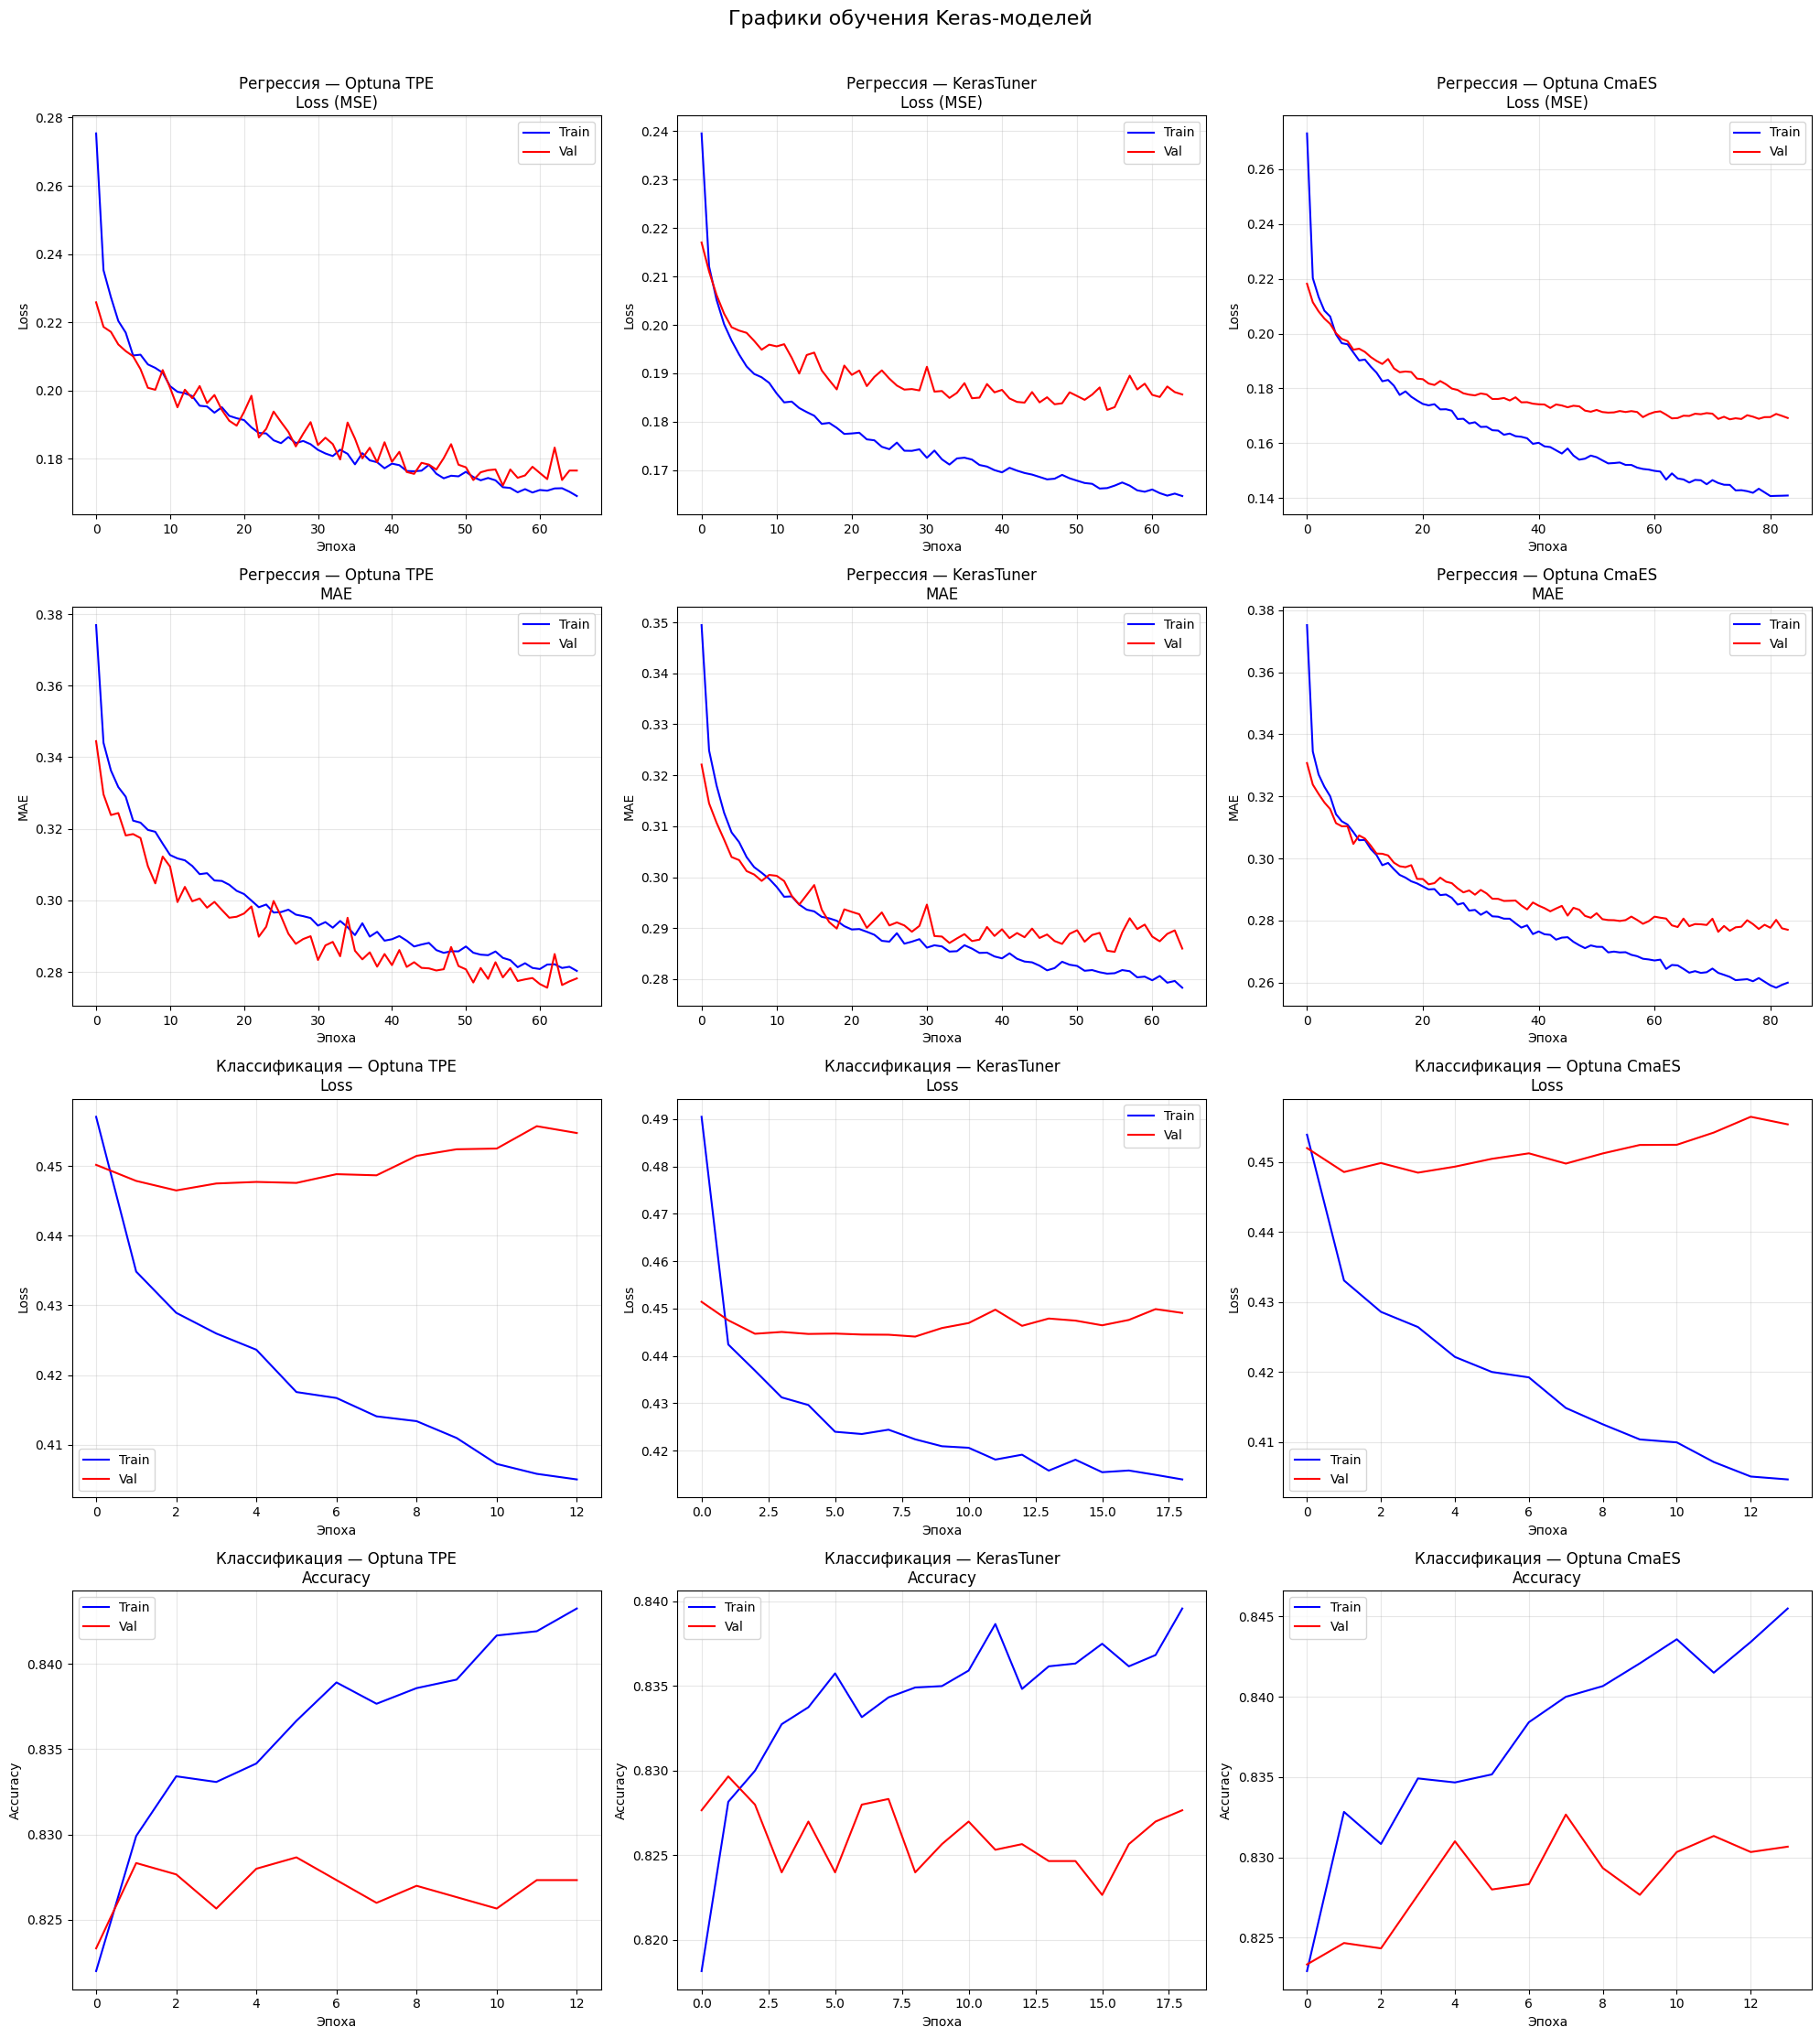

In [45]:
fig, axes = plt.subplots(4, 3, figsize=(20, 22))

reg_histories   = {'Optuna TPE': history_keras_reg_optuna, 'KerasTuner': history_keras_reg_kt,   'Optuna CmaES': history_keras_reg_cma}
class_histories = {'Optuna TPE': history_keras_class_optuna,'KerasTuner': history_keras_class_kt, 'Optuna CmaES': history_keras_class_cma}

for idx, (name, h) in enumerate(reg_histories.items()):
    axes[0,idx].plot(h.history['loss'], label='Train', color='blue')
    axes[0,idx].plot(h.history['val_loss'], label='Val', color='red')
    axes[0,idx].set(title=f'Регрессия — {name}\nLoss (MSE)', xlabel='Эпоха', ylabel='Loss')
    axes[0,idx].legend(); axes[0,idx].grid(alpha=0.3)

for idx, (name, h) in enumerate(reg_histories.items()):
    axes[1,idx].plot(h.history['mae'], label='Train', color='blue')
    axes[1,idx].plot(h.history['val_mae'], label='Val', color='red')
    axes[1,idx].set(title=f'Регрессия — {name}\nMAE', xlabel='Эпоха', ylabel='MAE')
    axes[1,idx].legend(); axes[1,idx].grid(alpha=0.3)

for idx, (name, h) in enumerate(class_histories.items()):
    axes[2,idx].plot(h.history['loss'], label='Train', color='blue')
    axes[2,idx].plot(h.history['val_loss'], label='Val', color='red')
    axes[2,idx].set(title=f'Классификация — {name}\nLoss', xlabel='Эпоха', ylabel='Loss')
    axes[2,idx].legend(); axes[2,idx].grid(alpha=0.3)

for idx, (name, h) in enumerate(class_histories.items()):
    axes[3,idx].plot(h.history['accuracy'], label='Train', color='blue')
    axes[3,idx].plot(h.history['val_accuracy'], label='Val', color='red')
    axes[3,idx].set(title=f'Классификация — {name}\nAccuracy', xlabel='Эпоха', ylabel='Accuracy')
    axes[3,idx].legend(); axes[3,idx].grid(alpha=0.3)

plt.suptitle('Графики обучения Keras-моделей', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Оценка качества моделей
### 5.1. Метрики регрессии

In [46]:
from sklearn.metrics import mean_absolute_percentage_error

reg_models = {
    'Sklearn+Optuna':    (mlp_reg_optuna,   mlp_reg_optuna.solver),
    'Sklearn+RandomCV':  (mlp_reg_rscv,     mlp_reg_rscv.solver),
    'Sklearn+Hyperopt':  (mlp_reg_hyperopt, mlp_reg_hyperopt.solver),
    'Keras+Optuna TPE':  (keras_reg_optuna, best_p['optimizer']),
    'Keras+KerasTuner':  (keras_reg_kt,     '—'),
    'Keras+Optuna CmaES':(keras_reg_cma,    best_p_cma['optimizer']),
}

rows = []
for name, (model, solver) in reg_models.items():
    is_keras = 'Keras' in name
    def pred(X, m=model, k=is_keras):
        p = m.predict(X, verbose=0).flatten() if k else m.predict(X)
        return scaler_y_reg.inverse_transform(p.reshape(-1,1)).ravel() if k else p
    yp_tr = pred(X_train_reg_selected); yp_te = pred(X_test_reg_selected)
    rows.append({'Модель': name, 'Оптимизатор': solver,
                 'Train R²': round(r2_score(y_train_reg, yp_tr),4),
                 'Train MAE': round(mean_absolute_error(y_train_reg, yp_tr),2),
                 'Test R²':  round(r2_score(y_test_reg, yp_te),4),
                 'Test MAE': round(mean_absolute_error(y_test_reg, yp_te),2),
                 'Test MSE': round(mean_squared_error(y_test_reg, yp_te),2)})

df_reg_results = pd.DataFrame(rows)
print(df_reg_results.to_string(index=False))
best_reg_name = df_reg_results.loc[df_reg_results['Test R²'].idxmax(), 'Модель']
print(f"\n🏆 Лучшая модель: {best_reg_name}  |  Test R²={df_reg_results['Test R²'].max()}")

            Модель Оптимизатор  Train R²  Train MAE  Test R²  Test MAE   Test MSE
    Sklearn+Optuna       lbfgs    0.8683    1263.40   0.8438   1362.68 4172847.91
  Sklearn+RandomCV       lbfgs    0.8624    1288.06   0.8424   1375.31 4208701.80
  Sklearn+Hyperopt       lbfgs    0.8677    1265.75   0.8351   1375.13 4404499.61
  Keras+Optuna TPE     rmsprop    0.8510    1325.44   0.8387   1409.73 4307864.00
  Keras+KerasTuner           —    0.8439    1358.53   0.8288   1453.34 4572410.50
Keras+Optuna CmaES        adam    0.8674    1268.12   0.8394   1396.04 4290717.50

🏆 Лучшая модель: Sklearn+Optuna  |  Test R²=0.8438


### 5.2. Метрики классификации

In [47]:
class_models = {
    'Sklearn+Optuna':    (mlp_class_optuna,   mlp_class_optuna.solver),
    'Sklearn+RandomCV':  (mlp_class_rscv,     mlp_class_rscv.solver),
    'Sklearn+Hyperopt':  (mlp_class_hyperopt, mlp_class_hyperopt.solver),
    'Keras+Optuna TPE':  (keras_class_optuna, best_p_c['optimizer']),
    'Keras+KerasTuner':  (keras_class_kt,     '—'),
    'Keras+Optuna CmaES':(keras_class_cma,    best_p_cma_c['optimizer']),
}

rows_c = []
for name, (model, solver) in class_models.items():
    is_keras = 'Keras' in name
    def cpred(X, m=model, k=is_keras):
        return np.argmax(m.predict(X, verbose=0), axis=1) if k else m.predict(X)
    yp_tr = cpred(X_train_class_selected); yp_te = cpred(X_test_class_selected)
    rows_c.append({'Модель': name, 'Оптимизатор': solver,
                   'Train Acc': round(accuracy_score(y_train_class, yp_tr),4),
                   'Train F1':  round(f1_score(y_train_class, yp_tr, average='weighted'),4),
                   'Test Acc':  round(accuracy_score(y_test_class, yp_te),4),
                   'Test F1':   round(f1_score(y_test_class, yp_te, average='weighted'),4),
                   'Test Prec': round(precision_score(y_test_class, yp_te, average='weighted'),4),
                   'Test Rec':  round(recall_score(y_test_class, yp_te, average='weighted'),4)})

df_class_results = pd.DataFrame(rows_c)
print(df_class_results.to_string(index=False))
best_class_name = df_class_results.loc[df_class_results['Test F1'].idxmax(), 'Модель']
print(f"\n🏆 Лучшая модель: {best_class_name}  |  Test F1={df_class_results['Test F1'].max()}")

            Модель Оптимизатор  Train Acc  Train F1  Test Acc  Test F1  Test Prec  Test Rec
    Sklearn+Optuna        adam     0.8319    0.7824    0.8319   0.7825     0.7810    0.8319
  Sklearn+RandomCV         sgd     0.8325    0.7833    0.8326   0.7829     0.7824    0.8326
  Sklearn+Hyperopt        adam     0.8401    0.8037    0.8309   0.7920     0.7815    0.8309
  Keras+Optuna TPE     rmsprop     0.8373    0.8047    0.8324   0.7992     0.7872    0.8324
  Keras+KerasTuner           —     0.8355    0.8061    0.8319   0.8011     0.7881    0.8319
Keras+Optuna CmaES     rmsprop     0.8392    0.8098    0.8319   0.7999     0.7872    0.8319

🏆 Лучшая модель: Keras+KerasTuner  |  Test F1=0.8011


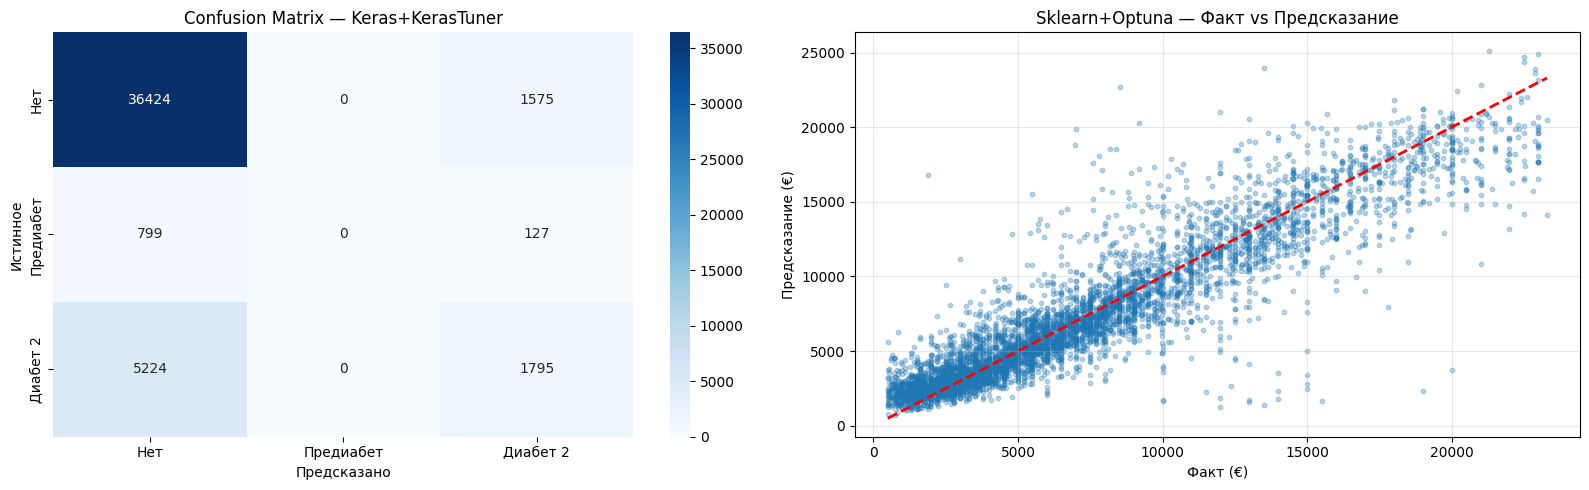

               precision    recall  f1-score   support

  Нет диабета       0.86      0.96      0.91     37999
    Предиабет       0.00      0.00      0.00       926
Диабет 2 типа       0.51      0.26      0.34      7019

     accuracy                           0.83     45944
    macro avg       0.46      0.40      0.42     45944
 weighted avg       0.79      0.83      0.80     45944



In [48]:
# Confusion Matrix
best_cls_model = class_models[best_class_name][0]
keras_best = 'Keras' in best_class_name
y_pred_best_class = (np.argmax(best_cls_model.predict(X_test_class_selected, verbose=0), axis=1)
                     if keras_best else best_cls_model.predict(X_test_class_selected))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cm = confusion_matrix(y_test_class, y_pred_best_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Нет','Предиабет','Диабет 2'], yticklabels=['Нет','Предиабет','Диабет 2'])
axes[0].set(title=f'Confusion Matrix — {best_class_name}', xlabel='Предсказано', ylabel='Истинное')

# Факт vs Предсказание для регрессии
best_reg_model_obj = reg_models[best_reg_name][0]
keras_r = 'Keras' in best_reg_name
y_pred_best_reg_raw = (best_reg_model_obj.predict(X_test_reg_selected, verbose=0).flatten()
                       if keras_r else best_reg_model_obj.predict(X_test_reg_selected))
y_pred_best_reg = (scaler_y_reg.inverse_transform(y_pred_best_reg_raw.reshape(-1,1)).ravel()
                   if keras_r else y_pred_best_reg_raw)
axes[1].scatter(y_test_reg, y_pred_best_reg, alpha=0.3, s=10)
axes[1].plot([y_test_reg.min(),y_test_reg.max()],[y_test_reg.min(),y_test_reg.max()],'r--',lw=2)
axes[1].set(title=f'{best_reg_name} — Факт vs Предсказание', xlabel='Факт (€)', ylabel='Предсказание (€)')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('results_viz.png', dpi=150, bbox_inches='tight'); plt.show()
print(classification_report(y_test_class, y_pred_best_class,
      target_names=['Нет диабета','Предиабет','Диабет 2 типа']))

---
## 6. Деплой модели

In [49]:
import joblib

joblib.dump(mlp_reg_optuna,    'best_sklearn_regression.pkl')
joblib.dump(mlp_class_optuna,  'best_sklearn_classification.pkl')
keras_reg_optuna.save('best_keras_regression.keras')
keras_class_optuna.save('best_keras_classification.keras')
joblib.dump(scaler_reg,              'scaler_reg.pkl')
joblib.dump(scaler_class,            'scaler_class.pkl')
joblib.dump(scaler_y_reg,            'scaler_y_reg.pkl')
joblib.dump(selector_reg_final,      'selector_reg.pkl')
joblib.dump(selector_class_final,    'selector_class.pkl')
print("✅ Все модели и препроцессоры сохранены!")

✅ Все модели и препроцессоры сохранены!


In [50]:
# ==================== ЗАПРОС — РЕГРЕССИЯ ====================
np.random.seed(7)
idx = np.random.randint(0, len(X_test_reg))
sample = X_test_reg.iloc[idx] if hasattr(X_test_reg, 'iloc') else X_test_reg[idx]
actual_price = y_test_reg[idx]

s_scaled   = scaler_reg.transform(sample.values.reshape(1,-1) if hasattr(sample,'values') else sample.reshape(1,-1))
s_selected = selector_reg_final.transform(s_scaled)

price_sklearn = mlp_reg_optuna.predict(s_selected)[0]
price_keras_s = keras_reg_optuna.predict(s_selected, verbose=0)
price_keras   = scaler_y_reg.inverse_transform(price_keras_s)[0][0]

print("=" * 60)
print("ЗАПРОС — РЕГРЕССИЯ (цена автомобиля)")
print("=" * 60)
print(f"Фактическая цена:       {actual_price:>10.0f} €")
print(f"Sklearn (Optuna):       {price_sklearn:>10.0f} €  (ошибка: {abs(actual_price-price_sklearn):.0f} €)")
print(f"Keras   (Optuna):       {price_keras:>10.0f} €  (ошибка: {abs(actual_price-price_keras):.0f} €)")

ЗАПРОС — РЕГРЕССИЯ (цена автомобиля)
Фактическая цена:             5800 €
Sklearn (Optuna):             4100 €  (ошибка: 1700 €)
Keras   (Optuna):             3788 €  (ошибка: 2012 €)


In [51]:
# ==================== ЗАПРОС — КЛАССИФИКАЦИЯ ====================
class_names = {0:'Нет диабета', 1:'Предиабет', 2:'Диабет 2 типа'}
idx_c = np.random.randint(0, len(X_test_class))
sample_c = X_test_class.iloc[idx_c] if hasattr(X_test_class,'iloc') else X_test_class[idx_c]
actual_class = y_test_class[idx_c]

sc_scaled   = scaler_class.transform(sample_c.values.reshape(1,-1) if hasattr(sample_c,'values') else sample_c.reshape(1,-1))
sc_selected = selector_class_final.transform(sc_scaled)

cls_sklearn     = mlp_class_optuna.predict(sc_selected)[0]
proba_sklearn   = mlp_class_optuna.predict_proba(sc_selected)[0]
proba_keras     = keras_class_optuna.predict(sc_selected, verbose=0)[0]
cls_keras       = np.argmax(proba_keras)

print("=" * 60)
print("ЗАПРОС — КЛАССИФИКАЦИЯ (диагностика диабета)")
print("=" * 60)
print(f"Фактический диагноз: {actual_class} — {class_names[actual_class]}")
print(f"\nSklearn (Optuna): {cls_sklearn} — {class_names[cls_sklearn]}")
for i,p in enumerate(proba_sklearn): print(f"  P({class_names[i]}): {p:.4f}")
print(f"\nKeras (Optuna):  {cls_keras} — {class_names[cls_keras]}")
for i,p in enumerate(proba_keras):   print(f"  P({class_names[i]}): {p:.4f}")

ЗАПРОС — КЛАССИФИКАЦИЯ (диагностика диабета)
Фактический диагноз: 0 — Нет диабета

Sklearn (Optuna): 0 — Нет диабета
  P(Нет диабета): 0.9679
  P(Предиабет): 0.0119
  P(Диабет 2 типа): 0.0201

Keras (Optuna):  0 — Нет диабета
  P(Нет диабета): 0.9588
  P(Предиабет): 0.0140
  P(Диабет 2 типа): 0.0273


---
## 7. Вывод

### Выполненная работа

В лабораторной работе №7 реализованы полносвязные нейронные сети (FCNN/MLP) для двух задач:
- **Регрессия** — предсказание цены автомобиля `Price(euro)` (Moldova Cars)
- **Классификация** — диагностика диабета `Diabetes_012` (Diabetes Health Indicators)

Два фреймворка: **Scikit-learn MLP** и **Keras/TensorFlow**.  
Три метода подбора гиперпараметров для каждого:
- Sklearn: **Optuna (TPE)**, **RandomizedSearchCV**, **Hyperopt**
- Keras: **Optuna (TPE)**, **KerasTuner**, **Optuna (CmaES)**

Оптимизаторы Sklearn: `adam`, `sgd`, `lbfgs`. Оптимизаторы Keras: `Adam`, `SGD`, `RMSprop`.

### TPE vs CmaES (Optuna)

**TPE (Tree-structured Parzen Estimator)** — строит вероятностную модель по предыдущим результатам и семплирует из перспективных областей. Хорошо работает в высокоразмерных пространствах с категориальными параметрами.

**CmaES (Covariance Matrix Adaptation Evolution Strategy)** — эволюционный алгоритм, адаптирующий ковариационную матрицу для поиска в непрерывном пространстве. Эффективнее TPE на задачах с числовыми параметрами (lr, dropout), но требует больше попыток для старта.

### Выводы

**Регрессия:** `Adam` и `RMSprop` сходятся быстрее `SGD` на данных с большим разбросом цен. Нормализация целевой переменной (`scaler_y_reg`) критически важна для Keras-моделей.

**Классификация:** При несбалансированных классах (`F1_weighted` как метрика) Keras с Dropout лучше обобщается. Optuna за то же число итераций стабильно превосходит RandomizedSearchCV благодаря адаптивному поиску.

**Кеширование:** все модели и результаты поиска сохраняются в директорию `lab7_cache/`.